# Chapter 7: Generative Models - GANs, VAEs and Diffusion

*Deep Learning Crash Course - BPB Publications*

We train a small DCGAN on MNIST, build a VAE on the same dataset, walk through a DDPM-style diffusion model on synthetic 2-D data, evaluate generative quality with FID, and finish with the chapter exercises.

Many cells in this chapter need a GPU for full-resolution faces. The notebook is sized to run end-to-end on CPU in a few minutes by using small models and MNIST.


## 1. Setup

In [1]:
import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)
def set_seed(s=42):
    os.environ['PYTHONHASHSEED']=str(s); random.seed(s); np.random.seed(s)
    try:
        import torch; torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    except ModuleNotFoundError: pass
set_seed(42)


## 2. A 1-D toy GAN

Before convolutional GANs, we visualise the minimax game on a 1-D bimodal target distribution. The generator's samples should converge onto the data's two modes.

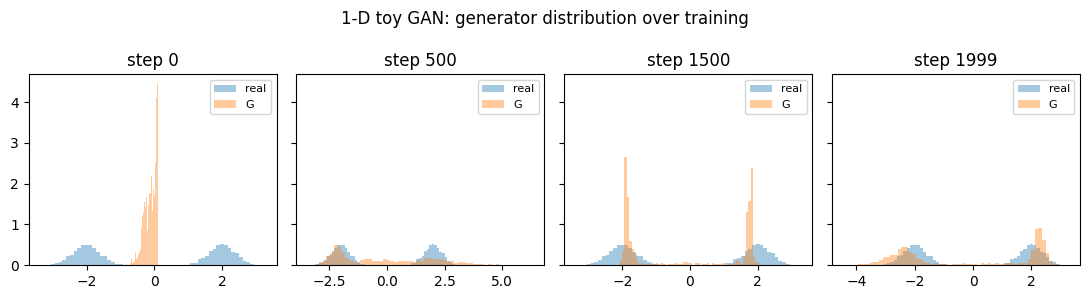

In [2]:
try:
    import torch
    import torch.nn as nn
    set_seed(0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def data_sampler(n):
        # bimodal: half samples around -2, half around +2
        x = torch.randn(n, 1) * 0.4
        mask = (torch.rand(n, 1) > 0.5).float()
        return x + mask * 2 - (1 - mask) * 2

    G = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 1)).to(device)
    D = nn.Sequential(nn.Linear(1, 32), nn.LeakyReLU(0.2), nn.Linear(32, 1)).to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=2e-3)
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-3)
    bce = nn.BCEWithLogitsLoss()

    snapshots = []
    for step in range(2000):
        real = data_sampler(128).to(device)
        z = torch.randn(128, 2, device=device)
        fake = G(z).detach()
        d_loss = bce(D(real), torch.ones_like(real)) + bce(D(fake), torch.zeros_like(real))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()
        z = torch.randn(128, 2, device=device)
        g_loss = bce(D(G(z)), torch.ones(128, 1, device=device))
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        if step in (0, 500, 1500, 1999):
            with torch.no_grad():
                z = torch.randn(2000, 2, device=device)
                snapshots.append((step, G(z).cpu().numpy().ravel()))

    fig, axes = plt.subplots(1, len(snapshots), figsize=(11, 3), sharey=True)
    real_all = data_sampler(5000).numpy().ravel()
    for ax, (s, samples) in zip(axes, snapshots):
        ax.hist(real_all, bins=60, alpha=0.4, label='real', density=True)
        ax.hist(samples, bins=60, alpha=0.4, label='G', density=True)
        ax.set_title(f'step {s}'); ax.legend(fontsize=8)
    fig.suptitle('1-D toy GAN: generator distribution over training')
    fig.tight_layout(); fig.savefig(IMG_DIR / '01_toy_gan.png', dpi=150); plt.show()
except ModuleNotFoundError:
    print('PyTorch not installed - skipping.')


## 3. Tiny DCGAN on MNIST

Stride-2 convolutions in the discriminator, transposed convolutions in the generator, BatchNorm everywhere, ReLU in G, LeakyReLU in D - the original DCGAN recipe.

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 686kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


epoch 0 step    0/469 d 1.391 g 0.862
epoch 0 step  100/469 d 0.017 g 5.317
epoch 0 step  200/469 d 3.150 g 0.979
epoch 0 step  300/469 d 0.391 g 2.474
epoch 0 step  400/469 d 0.556 g 0.740


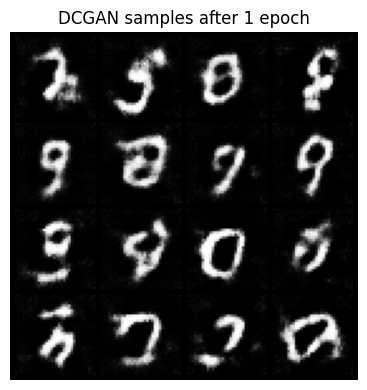

In [3]:
try:
    import torch
    import torch.nn as nn
    import torchvision
    from torchvision import transforms
    from torch.utils.data import DataLoader
    set_seed(0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    tf = transforms.Compose([transforms.Resize(32), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
    ds = torchvision.datasets.MNIST('./data', train=True, download=True, transform=tf)
    dl = DataLoader(ds, batch_size=128, shuffle=True)

    Z_DIM = 64
    class Generator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.ConvTranspose2d(Z_DIM, 128, 4, 1, 0), nn.BatchNorm2d(128), nn.ReLU(True),
                nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
                nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
                nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh())
        def forward(self, z): return self.net(z.view(z.size(0), Z_DIM, 1, 1))

    class Discriminator(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2, True),
                nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, True),
                nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
                nn.Conv2d(128, 1, 4, 1, 0))
        def forward(self, x): return self.net(x).view(-1)

    G = Generator().to(device); D = Discriminator().to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    fixed_z = torch.randn(16, Z_DIM, device=device)
    snaps = []
    EPOCHS = 1  # bump to 5+ for crisp samples on a GPU
    for ep in range(EPOCHS):
        for i, (x, _) in enumerate(dl):
            x = x.to(device); bs = x.size(0)
            z = torch.randn(bs, Z_DIM, device=device); fake = G(z)
            d_loss = bce(D(x), torch.ones(bs, device=device)) + bce(D(fake.detach()), torch.zeros(bs, device=device))
            opt_d.zero_grad(); d_loss.backward(); opt_d.step()
            z = torch.randn(bs, Z_DIM, device=device); fake = G(z)
            g_loss = bce(D(fake), torch.ones(bs, device=device))
            opt_g.zero_grad(); g_loss.backward(); opt_g.step()
            if i % 100 == 0:
                print(f'epoch {ep} step {i:4d}/{len(dl)} d {d_loss.item():.3f} g {g_loss.item():.3f}')
        with torch.no_grad():
            snaps.append(G(fixed_z).cpu())
    grid = torchvision.utils.make_grid(snaps[-1], nrow=4, normalize=True, value_range=(-1, 1))
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray'); ax.axis('off'); ax.set_title('DCGAN samples after 1 epoch')
    fig.tight_layout(); fig.savefig(IMG_DIR / '02_dcgan_samples.png', dpi=150); plt.show()
except ModuleNotFoundError:
    print('PyTorch or torchvision not installed - skipping.')


## 4. Variational autoencoder on MNIST

epoch 0 loss 133.29
epoch 1 loss 120.05


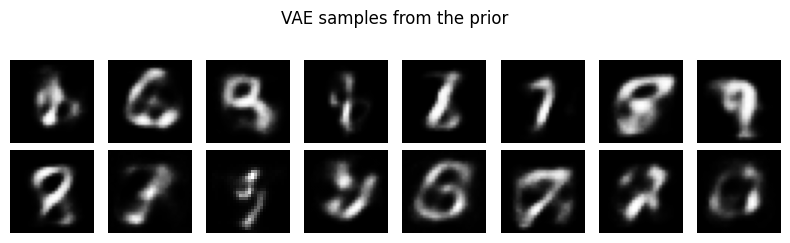

In [4]:
try:
    import torch
    import torch.nn as nn
    set_seed(0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    class VAE(nn.Module):
        def __init__(self, latent=16):
            super().__init__()
            self.fc1 = nn.Linear(784, 256); self.fc2 = nn.Linear(256, 2 * latent)
            self.fc3 = nn.Linear(latent, 256); self.fc4 = nn.Linear(256, 784)
            self.latent = latent
        def encode(self, x):
            h = torch.relu(self.fc1(x))
            mu, logvar = self.fc2(h).chunk(2, dim=1)
            return mu, logvar
        def decode(self, z):
            return torch.sigmoid(self.fc4(torch.relu(self.fc3(z))))
        def forward(self, x):
            mu, logvar = self.encode(x)
            std = torch.exp(0.5 * logvar)
            z = mu + std * torch.randn_like(std)
            return self.decode(z), mu, logvar

    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    tf = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
    train = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=tf), batch_size=128, shuffle=True)
    vae = VAE().to(device); opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
    for ep in range(2):
        for x, _ in train:
            x = x.to(device); recon, mu, lv = vae(x)
            bce = nn.functional.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
            kld = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum() / x.size(0)
            loss = bce + kld
            opt.zero_grad(); loss.backward(); opt.step()
        print(f'epoch {ep} loss {loss.item():.2f}')
    with torch.no_grad():
        z = torch.randn(16, 16, device=device)
        samples = vae.decode(z).view(-1, 28, 28).cpu().numpy()
    fig, axes = plt.subplots(2, 8, figsize=(8, 2.5))
    for ax, im in zip(axes.flat, samples): ax.imshow(im, cmap='gray'); ax.axis('off')
    fig.suptitle('VAE samples from the prior')
    fig.tight_layout(); fig.savefig(IMG_DIR / '03_vae_samples.png', dpi=150); plt.show()
except ModuleNotFoundError:
    print('PyTorch / torchvision not installed - skipping.')


## 5. Denoising diffusion on a 2-D Swiss-roll dataset

We learn $\varepsilon_\theta(x_t, t)$ on a synthetic 2-D distribution so the full forward and reverse processes can run in a notebook in seconds.

step    0 loss 0.9553
step  250 loss 0.7327
step  500 loss 0.7480
step  750 loss 0.7702
step 1000 loss 0.7990
step 1250 loss 0.6528


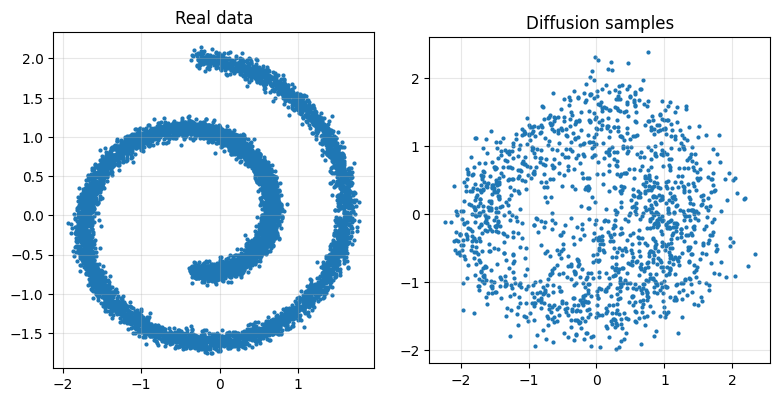

In [5]:
try:
    import torch
    import torch.nn as nn
    from sklearn.datasets import make_swiss_roll
    set_seed(0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    X, _ = make_swiss_roll(n_samples=8000, noise=0.4, random_state=0)
    X = X[:, [0, 2]]; X = (X - X.mean(0)) / X.std(0)
    X = torch.tensor(X, dtype=torch.float32)

    T = 100
    betas = torch.linspace(1e-4, 0.02, T)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)

    class Eps(nn.Module):
        def __init__(self, dim=2, h=128):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(dim + 1, h), nn.SiLU(),
                nn.Linear(h, h), nn.SiLU(),
                nn.Linear(h, dim))
        def forward(self, x, t):
            return self.net(torch.cat([x, t[:, None].float() / T], dim=1))

    model = Eps().to(device); opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for step in range(1500):
        idx = torch.randint(0, X.size(0), (256,))
        x0 = X[idx].to(device)
        t = torch.randint(0, T, (256,), device=device)
        eps = torch.randn_like(x0)
        sqrt_ab = alpha_bar[t.cpu()].sqrt().to(device)[:, None]
        sqrt_1_ab = (1 - alpha_bar[t.cpu()]).sqrt().to(device)[:, None]
        x_t = sqrt_ab * x0 + sqrt_1_ab * eps
        eps_hat = model(x_t, t)
        loss = ((eps - eps_hat) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 250 == 0: print(f'step {step:4d} loss {loss.item():.4f}')
    # Reverse sampling
    with torch.no_grad():
        x = torch.randn(1500, 2, device=device)
        for t in reversed(range(T)):
            tt = torch.full((x.size(0),), t, device=device, dtype=torch.long)
            eps = model(x, tt)
            beta = betas[t].to(device); a = alphas[t].to(device); ab = alpha_bar[t].to(device)
            mean = (x - beta / torch.sqrt(1 - ab) * eps) / torch.sqrt(a)
            noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
            x = mean + torch.sqrt(beta) * noise
    samples = x.cpu().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].scatter(X[:, 0], X[:, 1], s=4); axes[0].set_title('Real data')
    axes[1].scatter(samples[:, 0], samples[:, 1], s=4); axes[1].set_title('Diffusion samples')
    for ax in axes: ax.set_aspect('equal'); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(IMG_DIR / '04_diffusion_2d.png', dpi=150); plt.show()
except ModuleNotFoundError:
    print('PyTorch / sklearn not installed - skipping.')


## 6. Evaluating generative models - FID intuition

Full FID needs the Inception network. We illustrate the *concept* on a simple 2-D feature space - the same Gaussian-fit-and-Wasserstein-2 distance the real metric uses.

In [6]:
def fid_2d(real, fake):
    """Frechet distance between two 2-D Gaussians fitted to the given samples."""
    mu_r, mu_f = real.mean(0), fake.mean(0)
    Cr = np.cov(real.T) + 1e-6 * np.eye(real.shape[1])
    Cf = np.cov(fake.T) + 1e-6 * np.eye(fake.shape[1])
    diff = mu_r - mu_f
    # Frechet distance for Gaussians
    from scipy.linalg import sqrtm
    covmean = sqrtm(Cr @ Cf).real
    return float(diff @ diff + np.trace(Cr + Cf - 2 * covmean))

real = np.random.randn(2000, 2)
near = real + np.random.randn(*real.shape) * 0.1
far  = np.random.randn(2000, 2) + 4
print(f'FID-like(real, near): {fid_2d(real, near):.3f}')
print(f'FID-like(real, far):  {fid_2d(real, far):.3f}')


FID-like(real, near): 0.000
FID-like(real, far):  32.096


## 7. Exercise solutions

### 7.1 MCQ answer key

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) $p_g = p_{\text{data}}$ with $D^* = 1/2$ | Nash equilibrium of the minimax game. |
| 2 | (c) Strided convolutions replace pooling | DCGAN guideline 1. |
| 3 | (c) Generator collapses to a small subset of modes | Definition of mode collapse. |
| 4 | (b) 1-Lipschitz constraint on the discriminator | WGAN-GP enforces gradient norm 1. |
| 5 | (c) Concatenated to the noise vector | Standard cGAN conditioning. |
| 6 | (b) Works with unpaired data | Key advantage over Pix2Pix. |
| 7 | (c) Noise $\varepsilon$ added at step $t$ | DDPM training target. |
| 8 | (c) Latent space (post-VAE encoder) | Stable Diffusion is *latent* diffusion. |
| 9 | (c) ~5-10 | Modern GANs on CelebA report FID in this range. |
| 10 | (b) Sequence of patch embeddings | ViT chunks the image into patches. |
| 11 | (c) Two forward passes (conditional and unconditional) per step | CFG combines them. |
| 12 | (c) VAEs | Continuous, structured latent space supports smooth interpolation. |


### 7.2 Optimal discriminator derivation
For a fixed generator distribution $p_g$, the discriminator's loss is
$\mathcal{L}(D) = -\mathbb{E}_{p_{\text{data}}} \log D(x) - \mathbb{E}_{p_g} \log (1 - D(x))$.
Setting the functional derivative to zero gives
$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}$.
Substituting back into the value function shows that the generator's optimum is $p_g = p_{\text{data}}$, at which point $D^*(x) = 1/2$ everywhere - the discriminator is maximally uncertain. This is the Nash equilibrium.

### 7.3 Generator loss drops to zero with discriminator loss climbing
Pattern: vanishing-gradient + mode collapse. Three checks:
1. **Plot generator samples**: do you see only one or two faces? - mode collapse.
2. **Histogram of $D(G(z))$**: are predictions saturating at 0? - the discriminator has overpowered the generator.
3. **Per-batch standard deviation of $G(z)$**: collapse manifests as decreasing diversity.

Two remediations:
1. **Switch to WGAN-GP** loss with a gradient penalty - prevents vanishing gradients by removing the saturating sigmoid.
2. **Use a smaller D learning rate or skip D updates** when $D(G(z)) < 0.1$ so the generator can recover.

### 7.4 CycleGAN cycle-consistency vs Pix2Pix L1
Pix2Pix needs **paired** training data: for every source image you need the matching target. CycleGAN works on **unpaired** sets - you only need a pool of source images and a pool of target images. The cycle-consistency loss $||F(G(x)) - x||_1$ enforces that the round-trip translation reconstructs the original, which prevents the generator from collapsing all source images onto a single point of the target distribution. Removing the cycle loss would let the generator hallucinate any plausible target image regardless of the source, defeating the translation requirement.

### 7.5 DDPM ELBO and noise prediction
Variational lower bound on $\log p(x_0)$ decomposes into KL terms between $q(x_{t-1} | x_t, x_0)$ and $p_\theta(x_{t-1} | x_t)$. The forward process is closed-form Gaussian, so the KL is quadratic in the means. After algebra, the bound's $t$-th term is
$\mathbb{E}\left[ \frac{\beta_t^2}{2\sigma_t^2 \alpha_t (1-\bar\alpha_t)} || \varepsilon - \varepsilon_\theta(x_t, t) ||^2 \right]$.
Dropping the weighting coefficient gives the simple training objective used in practice. Predicting $\varepsilon$ rather than $x_0$ is equivalent (both are linear functions of each other through $x_t = \sqrt{\bar\alpha_t} x_0 + \sqrt{1-\bar\alpha_t} \varepsilon$) but yields gradients that are uniformly informative across noise levels.

### 7.6 Latent diffusion (Stable Diffusion) trade-offs
**Gained**: training and inference compute drop by ~$48^2 = 2304\times$ (image 512x512 -> latent 64x64). A consumer GPU can sample 512x512 images in seconds.
**Lost**: the VAE is itself a lossy compression - sharp text, faces and high-frequency details are more difficult to reconstruct than in pixel-space DDPM. Fine-grained errors (extra fingers, garbled text) often originate in the VAE, not the diffusion model.
**4 channels** instead of 3: Stable Diffusion's latent uses 4 channels because the VAE was trained jointly with the diffusion model and 4 channels gave a better reconstruction-fidelity / compute trade-off in ablations.

### 7.7 Generative pipeline for 500 chest X-rays
1. **Architecture choice**: a small DDPM is the safest pick - GANs are unstable on few-shot data, VAEs over-smooth medical detail.
2. **Hyper-parameters**: 4-block U-Net (32/64/128/256 channels), $T = 1000$ steps, cosine $\beta$ schedule, batch size 8 on a single GPU.
3. **Augmentation**: random flip, 5 percent contrast / brightness jitter, small affine rotations (max 5 degrees). Do NOT apply colour augmentation that could change pathology.
4. **Evaluation**:
   - Train the downstream classifier on (real only), (real + 1k synthetic), (real + 5k synthetic).
   - Compare AUC on a held-out *real* test set. If synthetic data hurts AUC, the diffusion model is hallucinating non-clinical features.
   - Have a radiologist eyeball 20 random samples for plausibility.


### 7.8 FID vs Inception Score
- **Inception Score** measures how peaked the predicted class distribution is for each generated sample and how diverse those distributions are across the set. It uses only the generator's samples - never the real data. It misses mode collapse to a single high-quality mode that the classifier happens to like.
- **FID** compares features of *both* real and generated samples in InceptionV3's pool-3 layer, fitting Gaussians and computing the Frechet distance. It catches drift in the feature distribution.
- Both fail on data the Inception network was not trained on. For 3-D, medical or scientific data, use a domain-specific feature extractor (e.g. a self-supervised model pre-trained on similar imagery) and replace InceptionV3 in the FID formula.

---
*End of Chapter 7.*
